# RQ2

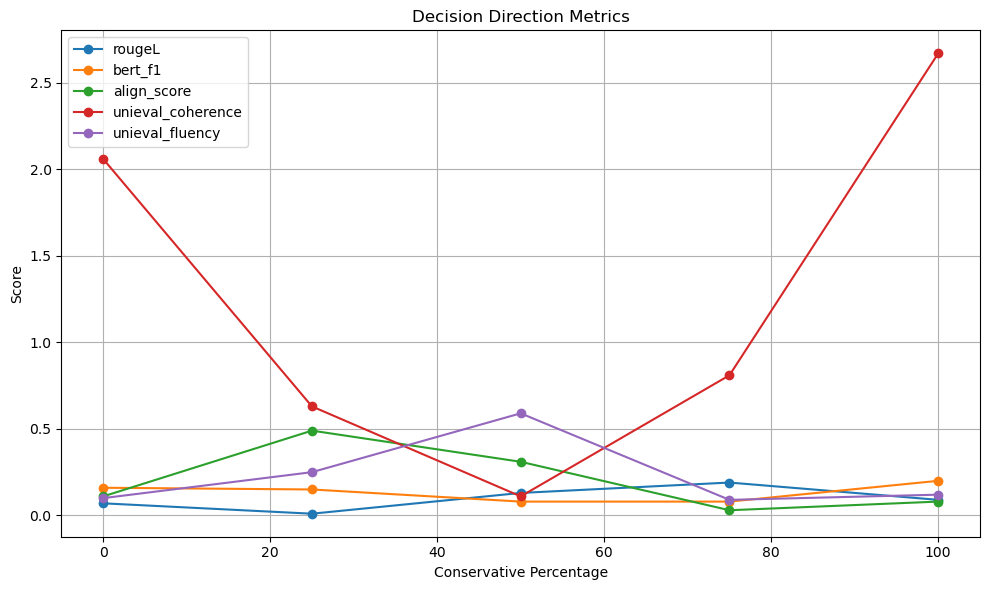

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
# Data for Decision Direction
decision_direction_data = {
    'Conservative%': [0, 25, 50, 75, 100],
    'Liberal%': [100, 75, 50, 25, 0],
    # 'rouge1': [0.46, 0.39, 0.16, 0.23, 0.24],
    # 'rouge2': [0.19, 0.08, 0.11, 0.10, 0.05],
    'rougeL': [0.07, 0.01, 0.13, 0.19, 0.09],
    'bert_f1': [0.16, 0.15, 0.08, 0.08, 0.20],
    'align_score': [0.11, 0.49, 0.31, 0.03, 0.08],
    'unieval_coherence': [2.06, 0.63, 0.11, 0.81, 2.67],
    # 'unieval_consistency': [0.66, 0.61, 0.54, 0.27, 0.25],
    'unieval_fluency': [0.10, 0.25, 0.59, 0.09, 0.12]
}
# Create DataFrame
decision_direction_df = pd.DataFrame(decision_direction_data)
def plot_metrics(df, title):
    plt.figure(figsize=(10, 6))
    x = df['Conservative%']
    for column in df.columns[2:]:  # Skip 'Conservative%' and 'Liberal%'
        plt.plot(x, df[column], marker='o', label=column)
    plt.title(title)
    plt.xlabel('Conservative Percentage')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
# Plot the Decision Direction metrics
plot_metrics(decision_direction_df, 'Decision Direction Metrics')

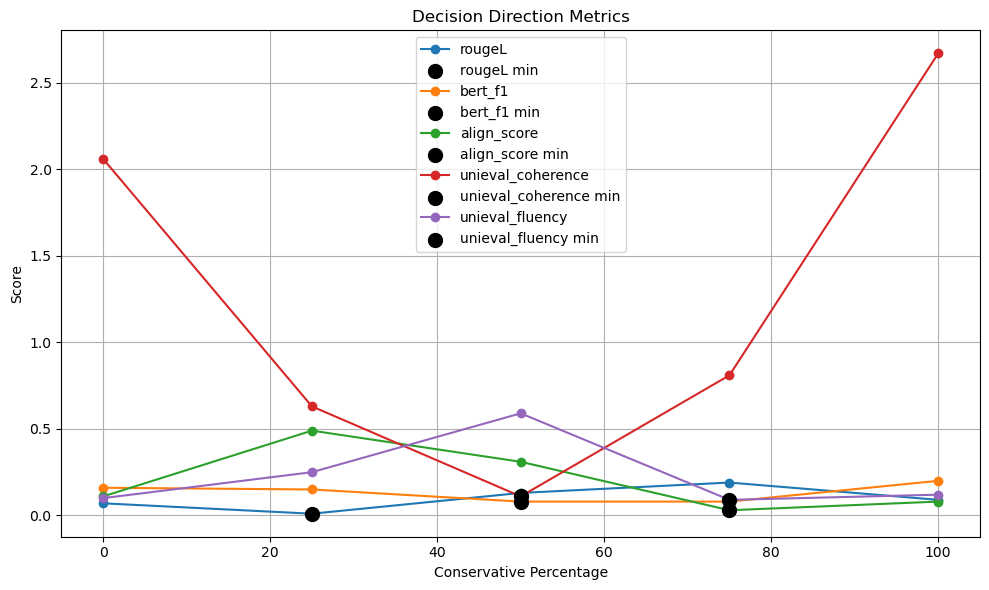

In [44]:
import matplotlib.pyplot as plt

def plot_metrics(df, title):
    plt.figure(figsize=(10, 6))
    x = df['Conservative%']
    
    for column in df.columns[2:]:  # Skip 'Conservative%' and 'Liberal%'
        y = df[column]
        plt.plot(x, y, marker='o', label=column)
        
        # Highlight the minimum value
        min_index = y.idxmin()
        plt.scatter(x[min_index], y[min_index], color='black', s=100, zorder=5, label=f'{column} min')
    
    plt.title(title)
    plt.xlabel('Conservative Percentage')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot the Decision Direction metrics
plot_metrics(decision_direction_df, 'Decision Direction Metrics')


In [27]:
import pandas as pd

# Data for Decision Direction
original_results_data = {
    'data-percentage': [
        'conservative', 'liberal', 'mixed', 'mixed_liberal_75', 'mixed_conservative_75',
        'liberal', 'mixed_conservative_75', 'mixed', 'conservative', 'mixed_liberal_75'
    ],
    'decisionDirection': [1, 1, 1, 1, 1, 2, 2, 2, 2, 2],
    # 'rouge1': [0.54, 0.56, 0.57, 0.57, 0.57, 0.57, 0.56, 0.57, 0.54, 0.56],
    # 'rouge2': [0.26, 0.27, 0.28, 0.28, 0.28, 0.28, 0.27, 0.28, 0.26, 0.27],
    'rougeL': [0.24, 0.24, 0.24, 0.24, 0.24, 0.24, 0.24, 0.24, 0.23, 0.24],
    'bert_f1': [0.65, 0.64, 0.65, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64, 0.64],
    'align_score': [0.68, 0.68, 0.69, 0.69, 0.69, 0.68, 0.69, 0.69, 0.69, 0.68],
    'unieval_coherence': [0.65, 0.66, 0.73, 0.68, 0.74, 0.70, 0.73, 0.73, 0.70, 0.70],
    # 'unieval_consistency': [0.61, 0.60, 0.61, 0.63, 0.61, 0.59, 0.61, 0.60, 0.61, 0.61],
    'unieval_fluency': [0.72, 0.71, 0.72, 0.71, 0.72, 0.71, 0.71, 0.71, 0.73, 0.70],
    # 'unieval_relevance': [0.61, 0.64, 0.71, 0.67, 0.73, 0.69, 0.71, 0.72, 0.67, 0.68],
    # 'unieval_overall': [0.65, 0.65, 0.69, 0.67, 0.70, 0.67, 0.69, 0.69, 0.68, 0.67]
}

# Create DataFrame
original_results_df = pd.DataFrame(original_results_data)


In [28]:
# Define the desired order
order = ['liberal', 'mixed_liberal_75', 'mixed', 'mixed_conservative_75', 'conservative']

# Convert 'data-percentage' to a categorical type with the specified order
original_results_df['data-percentage'] = pd.Categorical(
    original_results_df['data-percentage'],
    categories=order,
    ordered=True
)

# Sort the DataFrame based on the new categorical order
original_results_df.sort_values(by=['decisionDirection', 'data-percentage'], inplace=True)


In [29]:
# Multiply all columns except 'decisionDirection' by 100
original_results_df.iloc[:, 2:] = original_results_df.iloc[:, 2:] * 100


In [ ]:
import matplotlib.pyplot as plt

def plot_metrics(df, title, decision_direction):
    plt.figure(figsize=(12, 8))
    # Filter data for the specific decision direction
    df_filtered = df[df['decisionDirection'] == decision_direction]
    x = df_filtered['data-percentage']
    for column in df_filtered.columns[2:]:  # Skip 'data-percentage' and 'decisionDirection'
        plt.plot(x, df_filtered[column], marker='o', label=column)
    plt.title(f"{title} - Decision Direction {decision_direction}")
    plt.xlabel('Data Percentage')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot the original results for each decision direction
plot_metrics(original_results_df, 'Original Results Metrics', decision_direction=1)
plot_metrics(original_results_df, 'Original Results Metrics', decision_direction=2)


In [ ]:
#plot with max values

import matplotlib.pyplot as plt

def plot_metrics(df, title, decision_direction):
    plt.figure(figsize=(12, 8))
    # Filter data for the specific decision direction
    df_filtered = df[df['decisionDirection'] == decision_direction]
    x = df_filtered['data-percentage']
    
    for column in df_filtered.columns[2:]:  # Skip 'data-percentage' and 'decisionDirection'
        y = df_filtered[column]
        plt.plot(x, y, marker='o', label=column)
        
        # Highlight all maximum values
        max_value = y.max()
        max_indices = y[y == max_value].index
        
        for max_index in max_indices:
            plt.scatter(x[max_index], y[max_index], color='black', s=100, zorder=5, label=f'{column} max')
        
        # Highlight the minimum value
        min_index = y.idxmin()
        # plt.scatter(x[min_index], y[min_index], color='red', s=100, zorder=5, label=f'{column} min')
    
    plt.title(f"{title} - Decision Direction {decision_direction}")
    plt.xlabel('Data Percentage')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot the original results for each decision direction
plot_metrics(original_results_df, 'Original Results Metrics', decision_direction=1)
plot_metrics(original_results_df, 'Original Results Metrics', decision_direction=2)


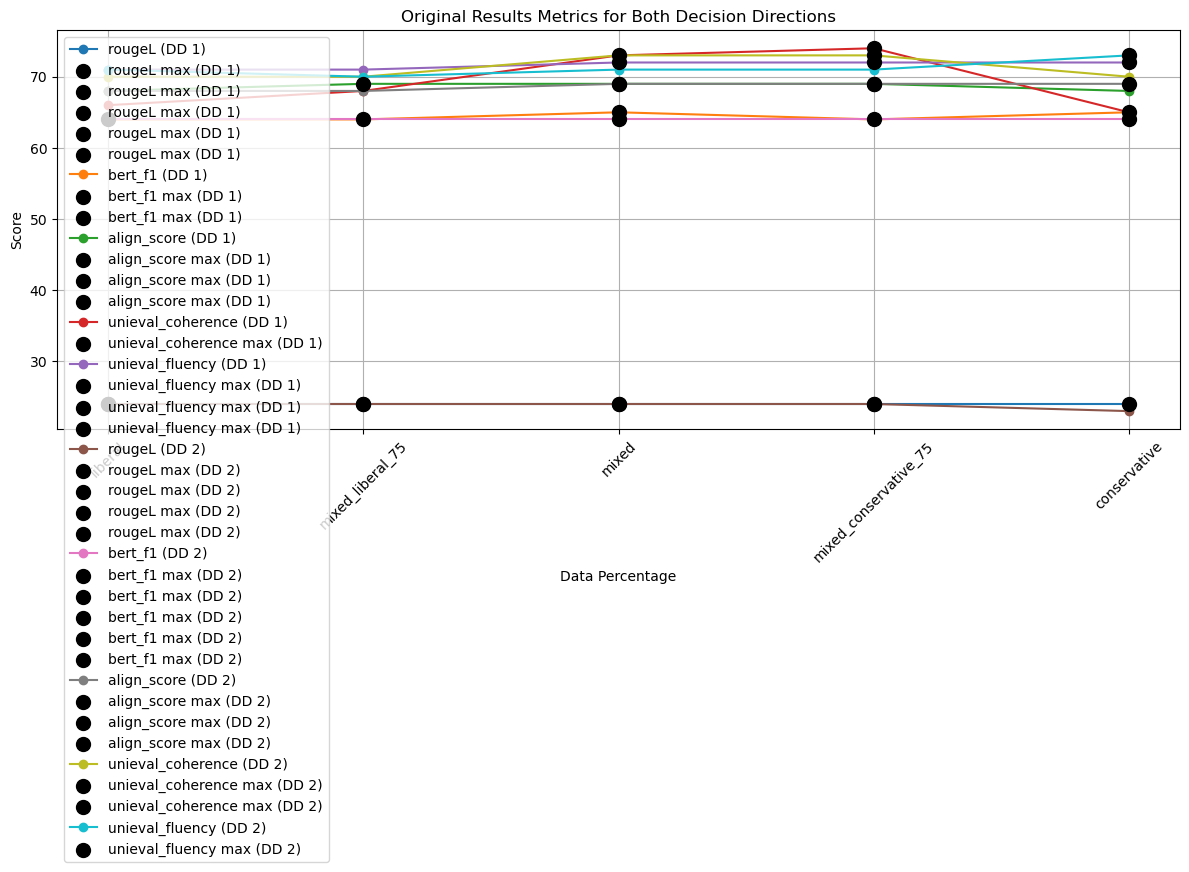

In [31]:
# plot both direction in one plot

import matplotlib.pyplot as plt

def plot_metrics(df, title):
    plt.figure(figsize=(12, 8))
    
    # Iterate over each decision direction
    decision_directions = df['decisionDirection'].unique()
    for decision_direction in decision_directions:
        # Filter data for the specific decision direction
        # df_filtered = df[df['data-percentage'].isin(['mixed', 'mixed_conservative_75'])]

        df_filtered = df[df['decisionDirection'] == decision_direction]
        
        x = df_filtered['data-percentage']
        
        for column in df_filtered.columns[2:]:  # Skip 'data-percentage' and 'decisionDirection'
            y = df_filtered[column]
            plt.plot(x, y, marker='o', label=f'{column} (DD {decision_direction})')
            
            # Highlight all maximum values
            max_value = y.max()
            max_indices = y[y == max_value].index
            
            for max_index in max_indices:
                plt.scatter(x[max_index], y[max_index], color='black', s=100, zorder=5, label=f'{column} max (DD {decision_direction})')
            
            # Highlight the minimum value
            min_index = y.idxmin()
            # plt.scatter(x[min_index], y[min_index], color='red', s=100, zorder=5, label=f'{column} min (DD {decision_direction})')
    
    plt.title(title)
    plt.xlabel('Data Percentage')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot the original results for both decision directions
plot_metrics(original_results_df, 'Original Results Metrics for Both Decision Directions')
